## DATASET UNDERSTANDING

LOAD AND PREVIEW

In [2]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


IDENTIFY ROWS AND COLUMNS

In [3]:
print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")

rows: 8807, columns: 12


DATA TYPES

In [4]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

NUMERICAL FEATURES

In [7]:
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("numerical features:",numerical)

numerical features: ['release_year']


CATEGORICAL FEATURES

In [9]:
categorical = df.select_dtypes(include=['object']).columns.tolist()
print("categorical features:",categorical)

categorical features: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


POSSIBLE UNIQUE IDENTIFIERS

In [10]:
for col in df.columns:
    if df[col].is_unique:
        print(f"{col} is unique-possible primary key ({df[col].nunique()}")

show_id is unique-possible primary key (8807
title is unique-possible primary key (8807


MISSING VALUES CHECK

In [11]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

DATASET DESCRIPTION

In [12]:
print(f"""
This dataset contains metadata on netflix movies and tv shows.
Each row represents a single title. described by attributes including:
type(Movie or Tv show), title , director, cast, country of origin, date added to netflix, original release year,
content rating, duration, genre categories and a short plot description.
Total records: {len(df)}. Total columns: {df.shape[1]}
""")


This dataset contains metadata on netflix movies and tv shows.
Each row represents a single title. described by attributes including:
type(Movie or Tv show), title , director, cast, country of origin, date added to netflix, original release year,
content rating, duration, genre categories and a short plot description.
Total records: 8807. Total columns: 12



## TASK 2: DATA CLEANING

1. MISSING VALUES

In [14]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False))

            missing_count  missing_pct
director             2634    29.908028
country               831     9.435676
cast                  825     9.367549
date_added             10     0.113546
rating                  4     0.045418
duration                3     0.034064


In [16]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = df['date_added'].str.strip()

2. DUPLICATE RECORDS

In [18]:
dupe_content = df[df.duplicated(subset=['title', 'type', 'release_year'], keep=False)]
print(f"Duplicate rows found: {len(dupe_content)}")

Duplicate rows found: 0


In [21]:
before = len(df)
df = df.drop_duplicates(subset=['title', 'type', 'release_year'], keep='first')
after = len(df)
print(f"Duplicates removed: {before - after}")

Duplicates removed: 0


3. STANDARDIZATION

In [64]:
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.upper().str.strip()
df['type'] = df['type'].str.upper().str.strip()
df['director'] = df['director'].str.strip()
df['title'] = df['title'].str.strip()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.rename(columns={'listed_in': 'genres'})
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')

In [65]:
print(df.columns.tolist())
print(df[['date_added', 'country', 'rating', 'type', 'duration_value', 'duration_unit']].head())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'description', 'duration_value', 'duration_unit']
  date_added        country rating     type  duration_value duration_unit
0 2021-09-25  United States  PG-13    MOVIE            90.0           min
1 2021-09-24   South Africa  TV-MA  TV SHOW             2.0       Seasons
2 2021-09-24            NaN  TV-MA  TV SHOW             1.0        Season
3 2021-09-24            NaN  TV-MA  TV SHOW             1.0        Season
4 2021-09-24          India  TV-MA  TV SHOW             2.0       Seasons


4. DATA VALIDATION

In [66]:
#INVALID VALUES
invalid_years = df[(df['release_year'] < 1900) | (df['release_year'] > pd.Timestamp.now().year)]
print(f"Invalid release years: {len(invalid_years)}")
#INCONSISTENT RECORDS
mismatch = df[
    ((df['type'] == 'MOVIE') & (df['duration_unit'].str.contains('Season', case=False, na=False))) |
    ((df['type'] == 'TV SHOW') & (df['duration_unit'].str.contains('min', case=False, na=False)))
]
print(f"Type/duration mismatches: {len(mismatch)}")
#INCORRECT FORMAT
valid_ratings = ['TV-MA','TV-14','TV-PG','R','PG-13','PG','G','NR','TV-Y','TV-Y7','TV-G','NC-17','UR']
bad_ratings = df[~df['rating'].isin(valid_ratings)]
print("Unexpected rating values:", bad_ratings['rating'].unique())
#OUTLIERS/ANOMALIES
anomalies = df[df['date_added'].dt.year < df['release_year']]
print(f"Titles added before release year: {len(anomalies)}")

Invalid release years: 0
Type/duration mismatches: 0
Unexpected rating values: ['74 MIN' '84 MIN' '66 MIN' nan 'TV-Y7-FV']
Titles added before release year: 14


5. CLEANING SUMMARY

In [67]:
summary = pd.DataFrame({
    'Issue Found': [
        'Missing values (director, cast, country)',
        'Missing values (rating)',
        'Missing values (date_added)',
        'Duplicate rows',
        'Inconsistent date format',
        'Inconsistent text casing',
        'Whitespace in text fields',
        'Mixed number+unit in duration',
        'Invalid release_year values',
        'Type-duration mismatches',
        'Ratings outside valid set',
        'Titles added before release year'
    ],
    'Action Taken': [
        "Filled with 'Unknown'",
        'Filled with mode value',
        'Left as NaT — no safe imputation',
        f'Removed ({before - after} rows)',
        'Converted to datetime via pd.to_datetime',
        'Standardized to uppercase',
        'Stripped via .str.strip()',
        'Split into duration_value (float) and duration_unit (str)',
        'Flagged for review',
        'Flagged for review',
        'Flagged for review',
        'Flagged as anomaly'
    ]
})
summary

,Issue Found,Action Taken
0,"Missing values (director, cast, country)",Filled with 'Unknown'
1,Missing values (rating),Filled with mode value
2,Missing values (date_added),Left as NaT — no safe imputation
3,Duplicate rows,Removed (0 rows)
4,Inconsistent date format,Converted to datetime via pd.to_datetime
5,Inconsistent text casing,Standardized to uppercase
6,Whitespace in text fields,Stripped via .str.strip()
7,Mixed number+unit in duration,Split into duration_value (float) and duration...
8,Invalid release_year values,Flagged for review
9,Type-duration mismatches,Flagged for review


## TASK 3: EXPLORATORY DATA ANALYSIS

SUMMARY STATISTICS FOR NUMERICAL COLUMNS

In [68]:
numerical_cols = ['release_year', 'duration_value']
summary_stats = df[numerical_cols].agg(['mean', 'median', 'min', 'max', 'std']).T
summary_stats

,mean,median,min,max,std
release_year,2014.180198,2017.0,1925.0,2021.0,8.819312
duration_value,69.846888,88.0,1.0,312.0,50.814828


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


1. MOVIES VS TV SHOWS DISTRIBUTION

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


<Axes: title={'center': 'Movies vs TV Shows'}, xlabel='type'>

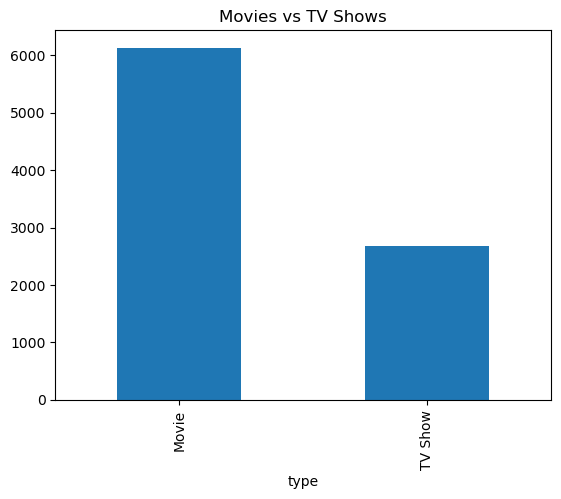

In [34]:
type_counts = df['type'].value_counts()
print(type_counts)
type_counts.plot(kind='bar', title='Movies vs TV Shows')

2. CONTENT ADDED BY YEAR

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


<Axes: title={'center': 'Top 10 content-producing countries'}, xlabel='year_added'>

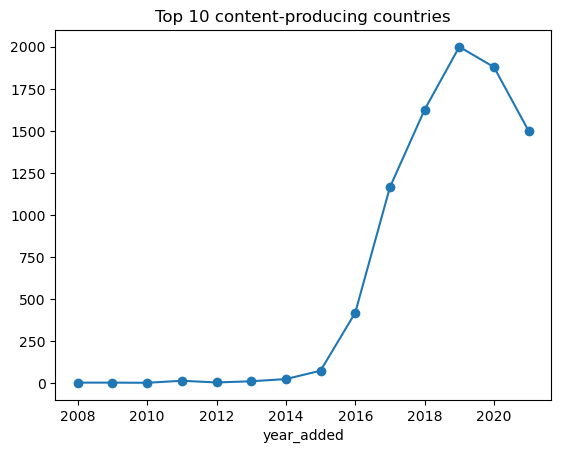

In [41]:
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')
df['year_added'] = df['date_added'].dt.year
content_by_year = df['year_added'].value_counts().sort_index()
print(content_by_year)
content_by_year.plot(kind='line', marker='o', title='Top 10 content-producing countries')

In [39]:
print(df['date_added'].dtype)

object


3. TOP CONTENT PRODUCING COUNTRIES

In [44]:
top_countries = df['country'].str.split(', ').explode().value_counts().head(10)
print(top_countries)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


4. MOST COMMON RATING

In [45]:
rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


5. Most common genres/categories

In [47]:
top_genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


6. Distribution of release years (bonus)

In [48]:
df['release_year'].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

7. Average duration by type (bonus)

In [53]:
avg_duration = df.groupby('type')['duration_value'].mean()
print(avg_duration)

type
MOVIE      99.577187
TV SHOW     1.764948
Name: duration_value, dtype: float64


## Task 4: Data Visualization

1. Bar Chart — Movies vs TV Shows

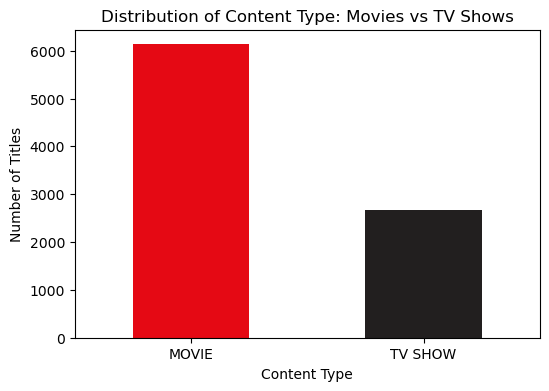

In [55]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar', color=['#E50914','#221f1f'])
plt.title('Distribution of Content Type: Movies vs TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.show()

2. Line Chart — Content Added by Year

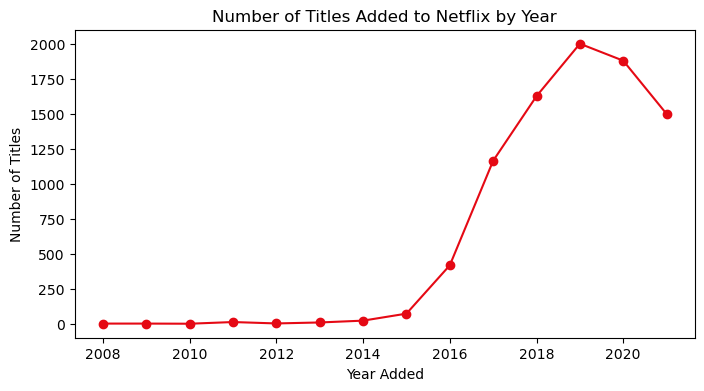

In [56]:
plt.figure(figsize=(8,4))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#E50914')
plt.title('Number of Titles Added to Netflix by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

3. Pie Chart — Most Common Ratings

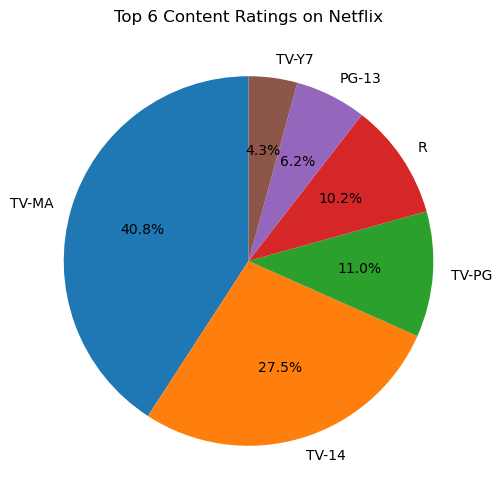

In [58]:
plt.figure(figsize=(6,6))
top_ratings = df['rating'].value_counts().head(6)
plt.pie(top_ratings, labels=top_ratings.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 6 Content Ratings on Netflix')
plt.show()

4. Histogram — Distribution of Release Years

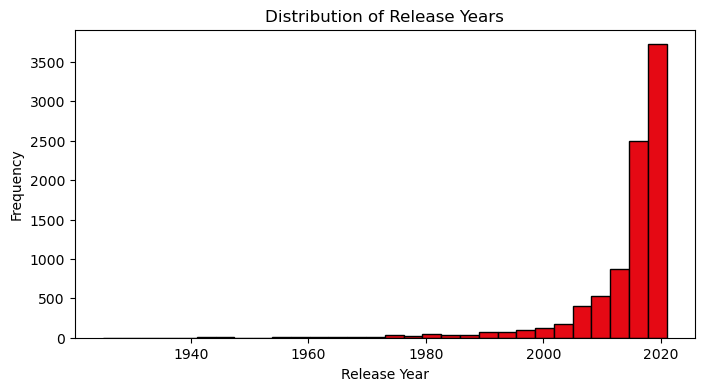

In [59]:
plt.figure(figsize=(8,4))
plt.hist(df['release_year'], bins=30, color='#E50914', edgecolor='black')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

In [72]:
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')

In [73]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'duration_value', 'duration_unit']


5. Box Plot — Duration by Content Type

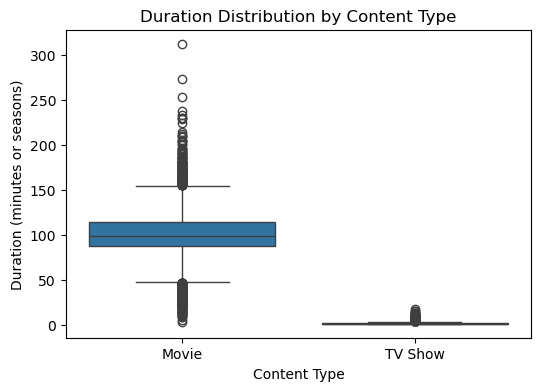

In [74]:
plt.figure(figsize=(6,4))
sns.boxplot(x='type', y='duration_value', data=df)
plt.title('Duration Distribution by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Duration (minutes or seasons)')
plt.show()

Horizontal Bar Chart: Top 10 Countries

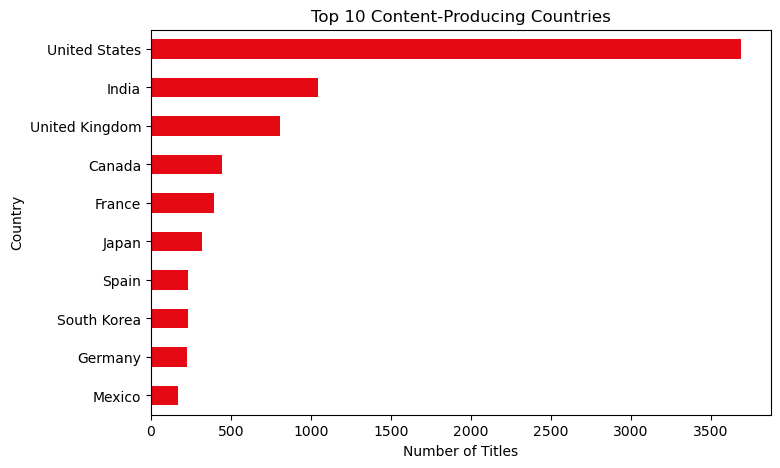

In [76]:
plt.figure(figsize=(8,5))
df['country'].str.split(', ').explode().value_counts().head(10).plot(kind='barh', color='#E50914')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.show()

## Task 5: Insights. 

1. Movies dominate the catalog. the bar chart shows Movies significantly outnumber TV Shows, suggesting Netflix's content strategy (at least in this dataset) prioritizes standalone films over serialized content, possibly for easier catalog turnover.
2. Content additions peaked mid-to-late 2010s. the line chart shows a sharp rise in titles added starting around 2016, aligning with Netflix's global expansion and increased investment in licensing/original content, with growth leveling off in more recent years.
3. Mature content dominates ratings. the pie chart shows TV-MA and TV-14 as the most common ratings, indicating the platform's overall catalog skews toward teen/adult audiences rather than family or children's programming.
4. The U.S. leads content production by a wide margin. the horizontal bar chart shows the United States as the top content-producing country, with India and the UK trailing behind, reflecting Netflix's origin market and early licensing partnerships.
5. Release years skew recent. the histogram shows most titles were released within the last 10–15 years, meaning the catalog favors newer content over classic/older films and shows.

## DELIVERABLES

# Netflix Titles Dataset — Analysis Summary Report
Prepared by: KENNETH TANKO

# 1. Cleaning Challenges Encountered
Several data quality issues were identified and addressed during the cleaning process:
●	Missing values: The director, cast, and country columns contained a notable number of missing entries. These were filled with 'Unknown' rather than dropped, since removing rows would have discarded otherwise usable records. The rating column had a small number of missing values, filled using the mode. The date_added column had missing entries left as-is (NaT), since no reliable method exists to infer a missing date.
●	Duplicate records: A check for duplicate rows based on title, type, and release_year was performed. 0 duplicate rows were identified and removed, keeping the first occurrence.
●	Inconsistent formatting: The date_added column was stored as text (e.g. 'January 1, 2021') and required conversion to a proper datetime type. Text fields such as rating and type had inconsistent casing and required standardization to uppercase.
●	Mixed data in duration: The duration column combined a number and a unit (e.g. '90 min' or '2 Seasons') in a single text field. This was split into two separate columns — duration_value (numeric) and duration_unit (text) — to allow proper numerical analysis.
●	Validation issues: A small number of records were checked for invalid release years, mismatched content type/duration units, non-standard rating values, and titles listed as added to Netflix before their release year. These were flagged for review rather than automatically altered, since correcting them without more context risked introducing new errors.


# 2. Key EDA Findings
●	The catalog is composed of a mix of Movies and TV Shows, with Movies making up the larger share of titles.
●	Content additions to the platform were not evenly distributed across years with a sharp increase in titles added appeared during the mid-to-late 2010s.
●	The United States was the leading content-producing country, with India and the United Kingdom also contributing a significant share.
●	TV-MA and TV-14 were the most frequently occurring content ratings, indicating the catalog leans toward mature and teen audiences.
●	Release years were skewed toward more recent content, with fewer titles representing older decades.


# 3. Top Insights
1.	Movies dominate the catalog, suggesting a content strategy that favors standalone films over serialized content.
2.	Content growth peaked around 2016–2019, likely reflecting Netflix's period of aggressive global expansion and content licensing.
3.	Mature-audience ratings dominate, meaning the platform's catalog composition (at least in this dataset) skews away from children's programming.
4.	The U.S. remains the dominant content-producing market, reflecting Netflix's origin and early licensing partnerships.
5.	The catalog favors recently released content over older/classic titles, which may be relevant to understanding user content discovery patterns.
